# Nori vs XGBoost on Clinical & Payer Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sechan9999/synthefy-nori/blob/main/examples/notebooks/nori-vs-xgboost-clinical.ipynb)

Can a training-free tabular foundation model replace a tuned gradient-boosted model for healthcare regression? This notebook compares **Nori** (in-context learning, no tuning) with **XGBoost** (randomized hyperparameter search) on three public datasets:

| Dataset | Rows | Target | Validation unit |
|---|---:|---|---|
| [Diabetes progression](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) (Efron et al., 2004) | 442 patients | Disease progression score at 1 year | Patient (repeated K-fold) |
| [Parkinson's telemonitoring](https://www.openml.org/d/4531) (Tsanas et al., 2010) | 5,875 recordings / 42 patients | Total UPDRS from voice measures | **Patient (GroupKFold)** |
| [CMS Medicare inpatient charges](https://www.openml.org/d/42130) (FY2011) | 4,000 sampled provider-DRG rows | Average total payment per discharge | Provider-DRG row (K-fold) |

Both models are scored on:

- **Accuracy**: R², RMSE, MAE on held-out folds.
- **Uncertainty**: empirical coverage and width of 90% prediction intervals. Nori reads them from its predictive distribution; XGBoost gets a separate quantile model (`reg:quantileerror`) using its tuned parameters.
- **Cost**: wall-clock fit + predict time, including XGBoost's search.
- **Small-data behavior**: a learning curve from 50 to 1,000 training rows.
- **Leakage**: what happens to both models' Parkinson's scores when recordings from the same patient land in both train and test.

## Setup

The saved outputs come from a CPU-only laptop run with `nori-6m`, 5 folds, and 30 XGBoost search configurations per fold; it took about two hours, most of it Nori on the 4,700-row Parkinson's contexts. On a GPU, set `NORI_MODEL=nori-30m` for the larger checkpoint. Set `QUICK=1` for a roughly 10-minute smoke run with fewer folds and search iterations.

In [1]:
# Install only when the runtime does not already have Nori.
try:
    import synthefy_nori  # noqa: F401
except ImportError:
    %pip install -q "synthefy-nori" xgboost matplotlib

In [2]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV, RepeatedKFold
from synthefy_nori import NoriRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

QUICK = os.environ.get("QUICK") == "1"
NORI_MODEL = os.environ.get("NORI_MODEL", "nori-6m")
N_SPLITS = 2 if QUICK else 5
XGB_SEARCH_ITERS = 3 if QUICK else 30
INTERVAL = (0.05, 0.95)  # 90% prediction interval
SEED = 0

print(f"Nori checkpoint: {NORI_MODEL} | folds: {N_SPLITS} | XGBoost search configs: {XGB_SEARCH_ITERS}")

Nori checkpoint: nori-6m | folds: 5 | XGBoost search configs: 30


## Load the datasets

- **Diabetes** uses the unscaled clinical units (age, BMI, blood pressure, six serum measures).
- **Parkinson's** drops `motor_UPDRS`: it is a sub-score of the target and would leak it. `subject.` is kept only as the grouping key.
- **Medicare** drops `average_medicare_payments`, which is a component of the target, and keeps DRG, state, discharge volume, and billed covered charges. A 4,000-row random sample keeps CPU runtime reasonable.

In [3]:
diabetes = load_diabetes(as_frame=True, scaled=False)
X_diab, y_diab = diabetes.data, diabetes.target.to_numpy(float)

pk = fetch_openml(data_id=4531, as_frame=True, parser="auto").frame
groups_pk = pk["subject."].to_numpy()
X_pk = pk.drop(columns=["subject.", "motor_UPDRS", "total_UPDRS"]).astype(float)
y_pk = pk["total_UPDRS"].to_numpy(float)

mc = fetch_openml(data_id=42130, as_frame=True, parser="auto").frame
mc = mc.sample(n=1000 if QUICK else 4000, random_state=SEED).reset_index(drop=True)
MEDICARE_CATS = ["drg_definition", "provider_state"]
X_mc = mc[MEDICARE_CATS + ["total_discharges", "average_covered_charges"]].copy()
for col in MEDICARE_CATS:
    X_mc[col] = X_mc[col].astype(str).astype("category")
y_mc = mc["average_total_payments"].to_numpy(float)

DATASETS = {
    "Diabetes": dict(X=X_diab, y=y_diab, groups=None, cats=None,
                     cv=RepeatedKFold(n_splits=N_SPLITS, n_repeats=1 if QUICK else 2, random_state=SEED)),
    "Parkinson's": dict(X=X_pk, y=y_pk, groups=groups_pk, cats=None, cv=GroupKFold(n_splits=N_SPLITS)),
    "Medicare": dict(X=X_mc, y=y_mc, groups=None, cats=MEDICARE_CATS,
                     cv=KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)),
}
pd.DataFrame({name: {"rows": len(d["y"]), "features": d["X"].shape[1],
                     "patients / groups": len(np.unique(d["groups"])) if d["groups"] is not None else "-",
                     "target mean": round(d["y"].mean(), 1), "target std": round(d["y"].std(), 1)}
              for name, d in DATASETS.items()}).T

,rows,features,patients / groups,target mean,target std
Diabetes,442,10,-,152.1,77.0
Parkinson's,5875.0,19.0,42.0,29.0,10.7
Medicare,4000,4,-,9799.1,7737.1


## The two contenders

**Nori** gets the raw table (no scaling, categoricals declared, no hyperparameters). One `predict(output_type="full")` call returns the mean and the full 999-quantile distribution, so the 90% interval costs nothing extra.

**XGBoost** is tuned by randomized search with inner cross-validation on the training fold only. Inner folds are grouped by patient when the outer split is, so tuning never sees a test patient. The interval model reuses the winning parameters with a two-quantile pinball objective.

In [4]:
XGB_SPACE = {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(2, 8),
    "learning_rate": loguniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": loguniform(1, 20),
    "reg_lambda": loguniform(0.1, 10),
}


def run_nori(X_tr, y_tr, X_te, cats):
    t0 = time.perf_counter()
    model = NoriRegressor(model=NORI_MODEL, categorical_columns=cats)
    model.fit(X_tr, y_tr)
    dist = model.predict(X_te, output_type="full")
    taus = np.asarray(dist["taus"])
    q = np.asarray(dist["quantiles"])
    lo = q[:, np.abs(taus - INTERVAL[0]).argmin()]
    hi = q[:, np.abs(taus - INTERVAL[1]).argmin()]
    return np.asarray(dist["mean"]), lo, hi, time.perf_counter() - t0


def run_xgb(X_tr, y_tr, X_te, groups_tr, n_iter=None):
    t0 = time.perf_counter()
    base = dict(tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=SEED)
    inner = GroupKFold(n_splits=3) if groups_tr is not None else KFold(n_splits=3, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(
        XGBRegressor(**base), XGB_SPACE, n_iter=n_iter or XGB_SEARCH_ITERS, cv=inner,
        scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=1,
    )
    search.fit(X_tr, y_tr, groups=groups_tr)
    pred = search.best_estimator_.predict(X_te)
    qmodel = XGBRegressor(**base, **search.best_params_, objective="reg:quantileerror",
                          quantile_alpha=np.array(INTERVAL))
    qmodel.fit(X_tr, y_tr)
    bounds = np.sort(qmodel.predict(X_te), axis=1)
    return pred, bounds[:, 0], bounds[:, 1], time.perf_counter() - t0


def score(y, pred, lo, hi, seconds):
    return {
        "R2": r2_score(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "MAE": mean_absolute_error(y, pred),
        "PI90 coverage": np.mean((y >= lo) & (y <= hi)),
        "PI90 width": np.mean(hi - lo),
        "seconds": seconds,
    }


def evaluate(name, X, y, groups, cats, cv):
    rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y[tr], y[te]
        g_tr = groups[tr] if groups is not None else None
        for label, runner in [("Nori", lambda: run_nori(X_tr, y_tr, X_te, cats)),
                              ("XGBoost", lambda: run_xgb(X_tr, y_tr, X_te, g_tr))]:
            rows.append({"dataset": name, "fold": fold, "model": label, **score(y_te, *runner())})
        print(f"{name} fold {fold}: Nori R2={rows[-2]['R2']:.3f} | XGBoost R2={rows[-1]['R2']:.3f}")
    return rows

## Head-to-head results

In [5]:
results = pd.DataFrame([row for name, d in DATASETS.items() for row in evaluate(name, **d)])
results.to_csv("nori_vs_xgboost_clinical_folds.csv", index=False)

summary = (results.groupby(["dataset", "model"])
           .agg(R2=("R2", "mean"), R2_sd=("R2", "std"), RMSE=("RMSE", "mean"), MAE=("MAE", "mean"),
                coverage=("PI90 coverage", "mean"), width=("PI90 width", "mean"), seconds=("seconds", "mean"))
           .round(3))
summary

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Diabetes fold 0: Nori R2=0.342 | XGBoost R2=0.306


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Diabetes fold 1: Nori R2=0.468 | XGBoost R2=0.453


Mixed precision is not supported for CPU inference, so it has been automatically disabled


...

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Medicare fold 3: Nori R2=0.854 | XGBoost R2=0.860


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Medicare fold 4: Nori R2=0.892 | XGBoost R2=0.879


R2  R2_sd      RMSE       MAE  coverage     width  \
dataset     model                                                           
Diabetes    Nori     0.488  0.087    54.722    44.466     0.907   171.116   
            XGBoost  0.475  0.107    55.295    45.203     0.839   173.149   
Medicare    Nori     0.868  0.015  2801.707  1542.092     0.925  6947.950   
            XGBoost  0.872  0.017  2760.744  1485.323     0.869  7600.641   
Parkinson's Nori    -0.759  0.495    13.094    10.884     0.195     8.451   
            XGBoost -0.268  0.429    10.988     9.107     0.753    26.937   

                     seconds  
dataset     model             
Diabetes    Nori       9.798  
            XGBoost   39.790  
Medicare    Nori     120.345  
            XGBoost   63.889  
Parkinson's Nori     376.259  
            XGBoost   96.939

In [6]:
wins = (results.pivot_table(index=["dataset", "fold"], columns="model", values="R2")
        .assign(nori_wins=lambda d: d["Nori"] > d["XGBoost"])
        .groupby("dataset")["nori_wins"].agg(["sum", "count"])
        .rename(columns={"sum": "Nori wins", "count": "folds"}))
wins

,Nori wins,folds
dataset,,
Diabetes,7,10
Medicare,2,5
Parkinson's,0,5


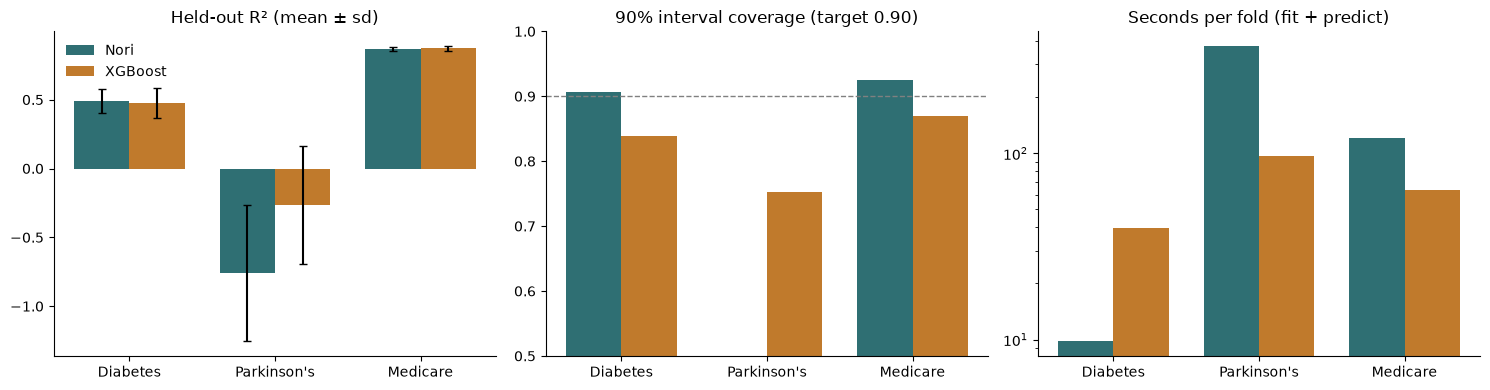

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"Nori": "#2f6f73", "XGBoost": "#c07a2c"}
names = list(DATASETS)
x = np.arange(len(names))
for i, model in enumerate(["Nori", "XGBoost"]):
    s = summary.xs(model, level="model").loc[names]
    axes[0].bar(x + (i - 0.5) * 0.38, s["R2"], 0.38, yerr=s["R2_sd"], label=model, color=colors[model], capsize=3)
    axes[1].bar(x + (i - 0.5) * 0.38, s["coverage"], 0.38, label=model, color=colors[model])
    axes[2].bar(x + (i - 0.5) * 0.38, s["seconds"], 0.38, label=model, color=colors[model])
axes[1].axhline(0.9, ls="--", c="grey", lw=1)
for ax, title in zip(axes, ["Held-out R² (mean ± sd)", "90% interval coverage (target 0.90)", "Seconds per fold (fit + predict)"]):
    ax.set_xticks(x, names)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].set_ylim(0.5, 1.0)
axes[2].set_yscale("log")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## How much data does each model need?

Clinical cohorts are often small: a single-site registry, a rare-disease panel, a new DRG. This curve holds a fixed 1,000-row Medicare test set and grows the training set from 50 rows, repeating each size three times with different draws.

In [8]:
SIZES = [50, 100, 250] if QUICK else [50, 100, 250, 500, 1000]
REPEATS = 1 if QUICK else 3
test_idx = np.random.default_rng(SEED).choice(len(y_mc), size=min(1000, len(y_mc) // 2), replace=False)
pool_idx = np.setdiff1d(np.arange(len(y_mc)), test_idx)
X_test_lc, y_test_lc = X_mc.iloc[test_idx], y_mc[test_idx]

curve = []
for size in SIZES:
    for rep in range(REPEATS):
        tr = np.random.default_rng(SEED + rep).choice(pool_idx, size=min(size, len(pool_idx)), replace=False)
        X_tr, y_tr = X_mc.iloc[tr], y_mc[tr]
        pred, *_ = run_nori(X_tr, y_tr, X_test_lc, MEDICARE_CATS)
        curve.append({"train rows": size, "rep": rep, "model": "Nori", "R2": r2_score(y_test_lc, pred)})
        pred, *_ = run_xgb(X_tr, y_tr, X_test_lc, None, n_iter=min(XGB_SEARCH_ITERS, 15))
        curve.append({"train rows": size, "rep": rep, "model": "XGBoost", "R2": r2_score(y_test_lc, pred)})
curve = pd.DataFrame(curve)
curve_summary = curve.pivot_table(index="train rows", columns="model", values="R2", aggfunc="mean").round(3)
curve_summary

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


...

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Mixed precision is not supported for CPU inference, so it has been automatically disabled


model,Nori,XGBoost
train rows,,
50,0.139,0.498
100,0.552,0.508
250,0.620,0.649
500,0.756,0.776
1000,0.809,0.834


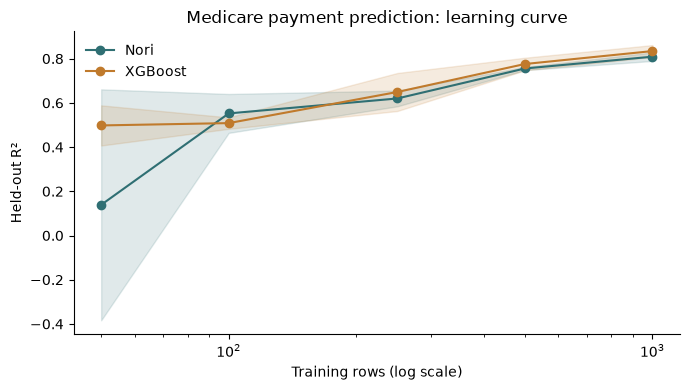

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for model, grp in curve.groupby("model"):
    agg = grp.groupby("train rows")["R2"].agg(["mean", "std"])
    ax.plot(agg.index, agg["mean"], marker="o", label=model, color=colors[model])
    ax.fill_between(agg.index, agg["mean"] - agg["std"], agg["mean"] + agg["std"], alpha=0.15, color=colors[model])
ax.set_xscale("log")
ax.set_xlabel("Training rows (log scale)")
ax.set_ylabel("Held-out R²")
ax.set_title("Medicare payment prediction: learning curve")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Leakage check: split by recording vs by patient

Each Parkinson's patient contributes about 140 voice recordings over six months. A random K-fold puts recordings from the same patient in both train and test, so a model can score well by recognizing the patient rather than learning how voice relates to symptom severity. The patient-grouped scores above are the honest ones; this cell shows how far a naive split would overstate them.

In [10]:
leaky = pd.DataFrame(evaluate("Parkinson's (random K-fold)", X_pk, y_pk, None, None,
                              KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)))
leak_table = pd.DataFrame({
    "patient-grouped R2": results[results.dataset == "Parkinson's"].groupby("model")["R2"].mean(),
    "random K-fold R2": leaky.groupby("model")["R2"].mean(),
})
leak_table["inflation"] = leak_table["random K-fold R2"] - leak_table["patient-grouped R2"]
leak_table.round(3)

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Parkinson's (random K-fold) fold 0: Nori R2=0.990 | XGBoost R2=0.963


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Parkinson's (random K-fold) fold 1: Nori R2=0.994 | XGBoost R2=0.971


Mixed precision is not supported for CPU inference, so it has been automatically disabled


...

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Parkinson's (random K-fold) fold 3: Nori R2=0.994 | XGBoost R2=0.970


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Parkinson's (random K-fold) fold 4: Nori R2=0.993 | XGBoost R2=0.972


,patient-grouped R2,random K-fold R2,inflation
model,,,
Nori,-0.759,0.993,1.752
XGBoost,-0.268,0.969,1.236


## Findings

**1. On small clinical cohorts, Nori matches tuned XGBoost with no tuning.** On Diabetes (442 patients, 5×2 CV), Nori's mean R² is **0.488** vs **0.475**, winning 7 of 10 folds. Its fit + predict took ~10 s per fold on CPU, vs ~40 s for XGBoost's 30-configuration search.

**2. On Medicare payments, it is a tie.** R² **0.868** vs **0.872**; XGBoost wins 3 of 5 folds by at most 0.021. With 3,200 context rows on CPU, Nori is now the slower one (~120 s vs ~64 s per fold).

**3. Nori's intervals are better calibrated when test rows resemble the context.** 90% interval coverage is **0.91** (Diabetes) and **0.93** (Medicare) for Nori, vs **0.84** and **0.87** for XGBoost's quantile model, at similar widths. Nori gets this from the same forward pass; XGBoost needs a second model and would still need conformal calibration to reach nominal coverage.

**4. Neither model generalizes Parkinson's severity to new patients, and Nori fails harder.** With whole patients held out, both R² values are negative (Nori **−0.76**, XGBoost **−0.27**; XGBoost wins all 5 folds). Voice features in this dataset track *which patient* a recording came from better than *how severe* their disease is. Nori's 90% intervals cover only **20%** of held-out patients' scores, against **75%** for XGBoost. Its predictive distribution is confidently wrong under patient-level distribution shift.

**5. Random splits hide that failure completely.** Splitting by recording instead of patient raises R² to **0.993** (Nori) and **0.969** (XGBoost), an inflation of +1.75 and +1.24. Nori benefits *more* from leakage because in-context learning can match a query to near-duplicate rows from the same patient. Any clinical benchmark of an ICL model needs a patient- or site-grouped split.

**6. Nori did not win the small-data regime here.** On the Medicare learning curve, Nori trails at 50 rows (mean R² 0.14 vs 0.50 over 3 draws) and is within ±0.05 of XGBoost from 100 to 1,000 rows (0.81 vs 0.83 at 1,000).

### When to reach for which

| Situation | Better default |
|---|---|
| Small cohort, need a strong baseline in minutes, calibrated intervals matter | **Nori** |
| Thousands of rows on CPU, or latency-sensitive scoring | **XGBoost** |
| Deployment to new patients, sites, or payers (distribution shift) | **XGBoost**, and validate both with grouped CV |
| Any model | Split by patient/provider before trusting a score |

### Limitations

- CPU run of the smallest checkpoint (`nori-6m`); `nori-30m`/`nori-100m` on a GPU may shift results 1–2 R² points.
- XGBoost search is 30 random configurations, not exhaustive; its quantile model reuses the point-model parameters.
- Medicare is a 4,000-row sample of 163k rows with a heavy-tailed target, split by row rather than by provider.
- Three datasets are a case study, not a benchmark suite; use the fold-level CSV (`nori_vs_xgboost_clinical_folds.csv`) for your own comparisons.